In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

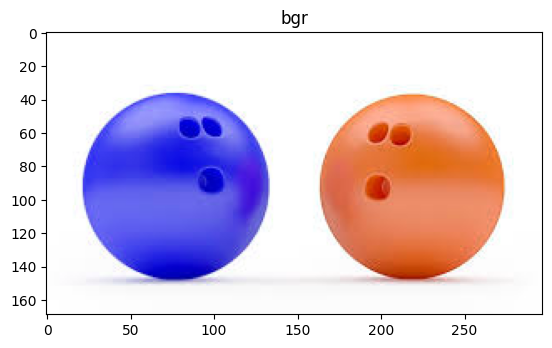

In [2]:
img = cv.imread('images/two-balls-image.jpeg')

def display(img, title):
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(title)
    plt.show()
display(img, 'bgr')

## 1. Color Space Conversion

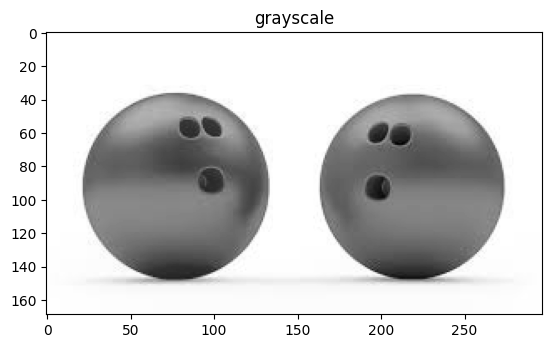

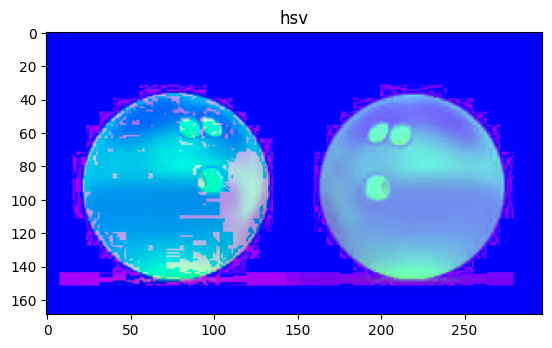

In [3]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
display(gray, 'grayscale')

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
display(hsv, 'hsv')

### 1.1 Thresholding

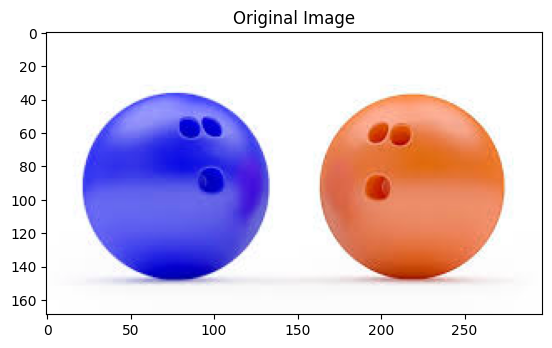

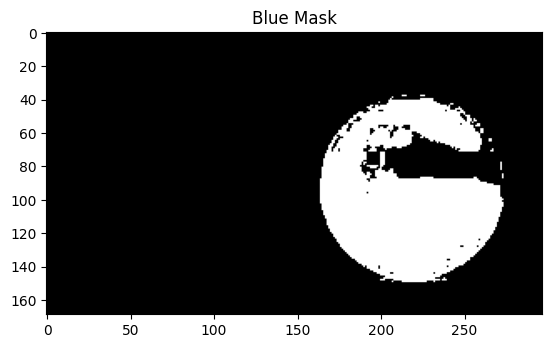

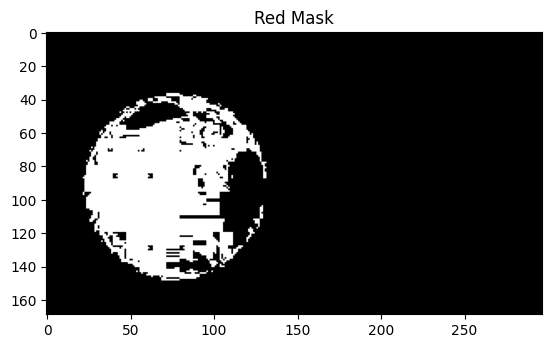

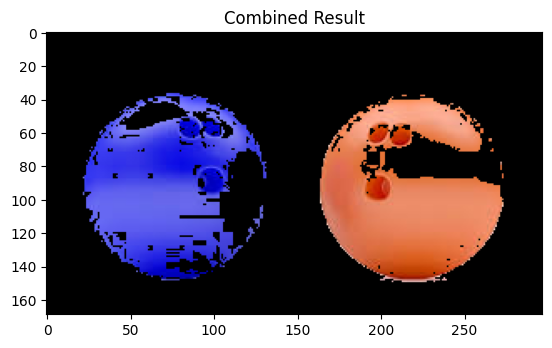

In [4]:
 # Define HSV range for BLUE
lower_blue = np.array([110,50,50])
upper_blue = np.array([130,255,255])

# Define HSV range for ORANGE
lower_orange = np.array([10, 100, 100])
upper_orange = np.array([25, 255, 255])

lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])



mask_blue = cv.inRange(hsv, lower_blue, upper_blue)
mask_red = cv.inRange(hsv, lower_red, upper_red)

# Combine both masks
combined_mask = cv.bitwise_or(mask_blue, mask_red)
                              
result = cv.bitwise_and(img, img, mask=combined_mask)
                              
display(img, 'Original Image')
display(mask_blue, 'Blue Mask')
display(mask_red, 'Red Mask')
display(result, 'Combined Result')


## 2. Geometric Transformation

### 2.1 Scaling

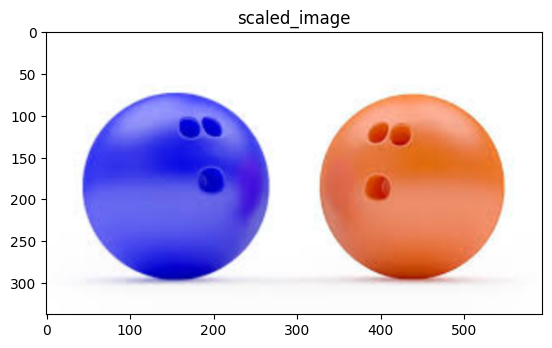

In [5]:
h,w = img.shape[:2]
scaled_img = cv.resize(img, (2*w,2*h), interpolation=cv.INTER_LINEAR)
display(scaled_img, 'scaled_image')

In [6]:
scaled_img.shape

(338, 594, 3)

### 2.2 Rotation


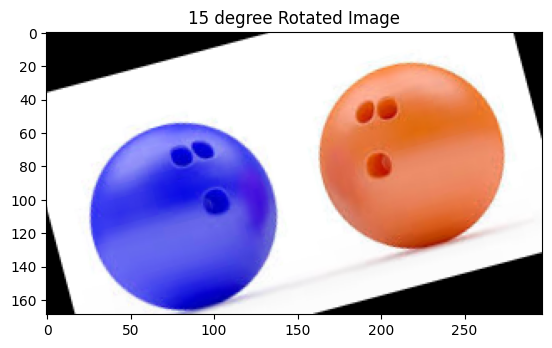

In [10]:
img = cv.imread('images/two-balls-image.jpeg')
h, w = img.shape[:2]

# Define a centre for rotation
centre = (w//2, h//2)
angle = 15
scale = 1.0 # The image retains its original size
rotation_matrix = cv.getRotationMatrix2D(centre, angle, scale) # Creates a 2×3 affine transformation matrix
rotated_image = cv.warpAffine(img, rotation_matrix, (w, h))
display(rotated_image, '15 degree Rotated Image')

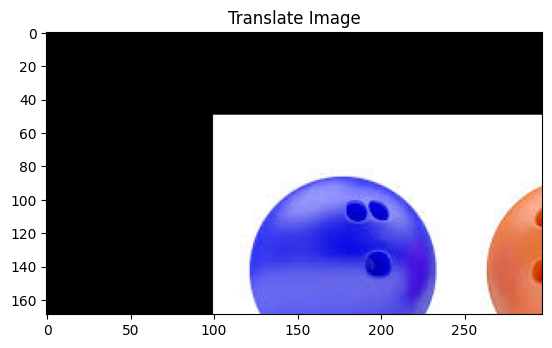

In [12]:
translation_matrix = np.float32([[1,0,100],[0,1,50]])
translated_img = cv.warpAffine(img, translation_matrix, (w,h))
display(translated_img, 'Translate Image')